# V3 moneyness performance — 1.5-year monthly calibration

**This notebook is the computational source of truth.** The matching PDF is written from the same payload.

This report classifies the **same** option contracts as `V4_1p5y_monthly_empirical_study` into DOTM / OTM / ATM / ITM / DITM. It does not change filters, calibration, contracts, LSM settings, or the market benchmark.

| Item | Setting |
|------|---------|
| Models | GBM, MD-GBM, GARCH, Heston, Merton, GARCH–Merton, Heston–Merton |
| Companies | SPY, AAPL, MSFT, AMZN (pooled in both analyses) |
| Regimes | Crisis, Normal, Late-cycle, COVID (pooled in Analysis 1; separate in Analysis 2) |
| Contracts | Monday nearest-ATM listed calls from the main study (`n = 802` per model) |
| Moneyness | `m = S/K` (calls) |
| Primary metric | RMSE% |
| Secondary | MAE%, **Bias%** |


## 0. Methodology

### Same design as the main study
1.5-year lookback, `monthly` recalibration, V3 filters (no-arbitrage, DTE 7–60, |S/K−1|≤10%, liquidity), Euler-corrected Heston, option-implied Heston NLS, LSM with 10,000 paths and seed 42. No look-ahead.

### Moneyness rule (calls)
Let `m = S/K`.

| Bucket | Rule |
|--------|------|
| DOTM | m < 0.98 |
| OTM | 0.98 ≤ m < 0.995 |
| ATM | 0.995 ≤ m ≤ 1.005 |
| ITM | 1.005 < m ≤ 1.02 |
| DITM | m > 1.02 |

These five bins partition the main-study 10% moneyness filter. The Monday ATM sampler concentrates mass in ATM.

### Metrics
- RMSE% = 100 × √ mean(((model − market)/market)²)
- MAE% = 100 × mean(|model − market|/market)
- Bias% = 100 × mean((model − market)/market)
- BEST = lowest RMSE% among models with n > 0


In [1]:
import sys
from pathlib import Path
from IPython.display import display, HTML
ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    scripts = cand / 'V4-Models_result' / 'scripts'
    if scripts.exists():
        sys.path.insert(0, str(scripts))
        break
import run_v4_1p5y_10k_monthly_moneyness_study as mx
panel = mx.load_panel()
payload = mx.build_payload(panel)
pdf = mx.write_pdf(payload)
print('n_overall', payload['n_overall'])
print('PDF', pdf)

## 1. Shared sample counts


In [1]:
display(HTML('counts'))

Regime,DOTM,OTM,ATM,ITM,DITM,Total
2008-2009,18,43,80,43,16,200
2013-2014,0,5,192,3,0,200
2018-2019,0,4,191,7,0,202
2019-2020,0,6,189,5,0,200
All,18,58,652,58,16,802


## 2. Analysis 1 — Overall moneyness


### Table M1. DOTM  ·  m < 0.98  ·  n = 18  ·  **BEST = Heston**


In [1]:
tab = payload['analysis1']['DOTM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE%,Bias%,Ranking
GBM,18,50.92,39.60,+27.94,7
MD-GBM,18,35.99,27.39,+3.50,4
GARCH,18,32.41,25.65,+19.46,2
Heston,18,30.32,25.07,+22.85,1
Merton,18,48.70,37.01,+35.27,6
GARCH–Merton,18,43.04,36.75,+35.01,5
Heston–Merton,18,33.39,28.41,+25.69,3


### Table M2. OTM  ·  0.98 ≤ m < 0.995  ·  n = 58  ·  **BEST = Heston**


In [1]:
tab = payload['analysis1']['OTM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE%,Bias%,Ranking
GBM,58,63.38,49.21,+34.97,7
MD-GBM,58,47.88,36.82,+13.34,3
GARCH,58,52.18,39.54,+30.61,4
Heston,58,35.39,30.25,+21.68,1
Merton,58,61.71,48.63,+41.46,5
GARCH–Merton,58,61.97,47.83,+43.13,6
Heston–Merton,58,40.28,34.19,+27.36,2


### Table M3. ATM  ·  0.995 ≤ m ≤ 1.005  ·  n = 652  ·  **BEST = MD-GBM**


In [1]:
tab = payload['analysis1']['ATM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE%,Bias%,Ranking
GBM,652,47.99,38.87,+30.16,4
MD-GBM,652,33.54,27.09,+10.33,1
GARCH,652,47.02,35.44,+29.21,3
Heston,652,38.14,30.23,+24.75,2
Merton,652,50.54,41.37,+35.42,6
GARCH–Merton,652,57.61,45.50,+42.06,7
Heston–Merton,652,50.06,41.44,+37.77,5


### Table M4. ITM  ·  1.005 < m ≤ 1.02  ·  n = 58  ·  **BEST = Heston**


In [1]:
tab = payload['analysis1']['ITM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE%,Bias%,Ranking
GBM,58,38.61,31.48,+13.60,5
MD-GBM,58,31.08,25.55,-2.12,3
GARCH,58,41.32,32.10,+24.66,6
Heston,58,25.88,21.53,+9.88,1
Merton,58,37.15,30.51,+19.81,4
GARCH–Merton,58,50.60,40.78,+37.89,7
Heston–Merton,58,29.55,25.77,+16.08,2


### Table M5. DITM  ·  m > 1.02  ·  n = 16  ·  **BEST = Heston**


In [1]:
tab = payload['analysis1']['DITM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE%,Bias%,Ranking
GBM,16,35.18,28.19,+16.72,6
MD-GBM,16,27.26,23.27,-0.08,3
GARCH,16,32.43,24.65,+19.14,4
Heston,16,16.35,14.20,+12.19,1
Merton,16,33.37,24.52,+23.76,5
GARCH–Merton,16,40.15,31.54,+31.54,7
Heston–Merton,16,21.49,19.00,+17.43,2


### Figure M1 — Model × Moneyness RMSE% heatmap


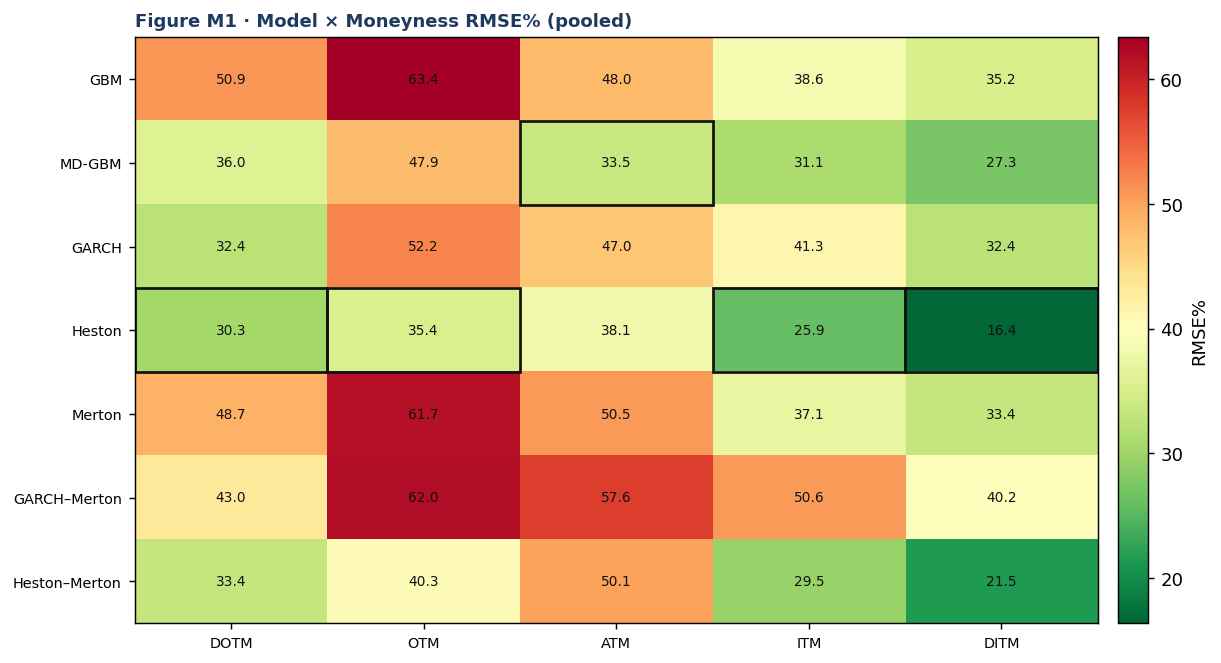

In [1]:
pass

## 3. Analysis 2 — Regime × moneyness


### Figure M2 — RMSE% heatmaps by regime


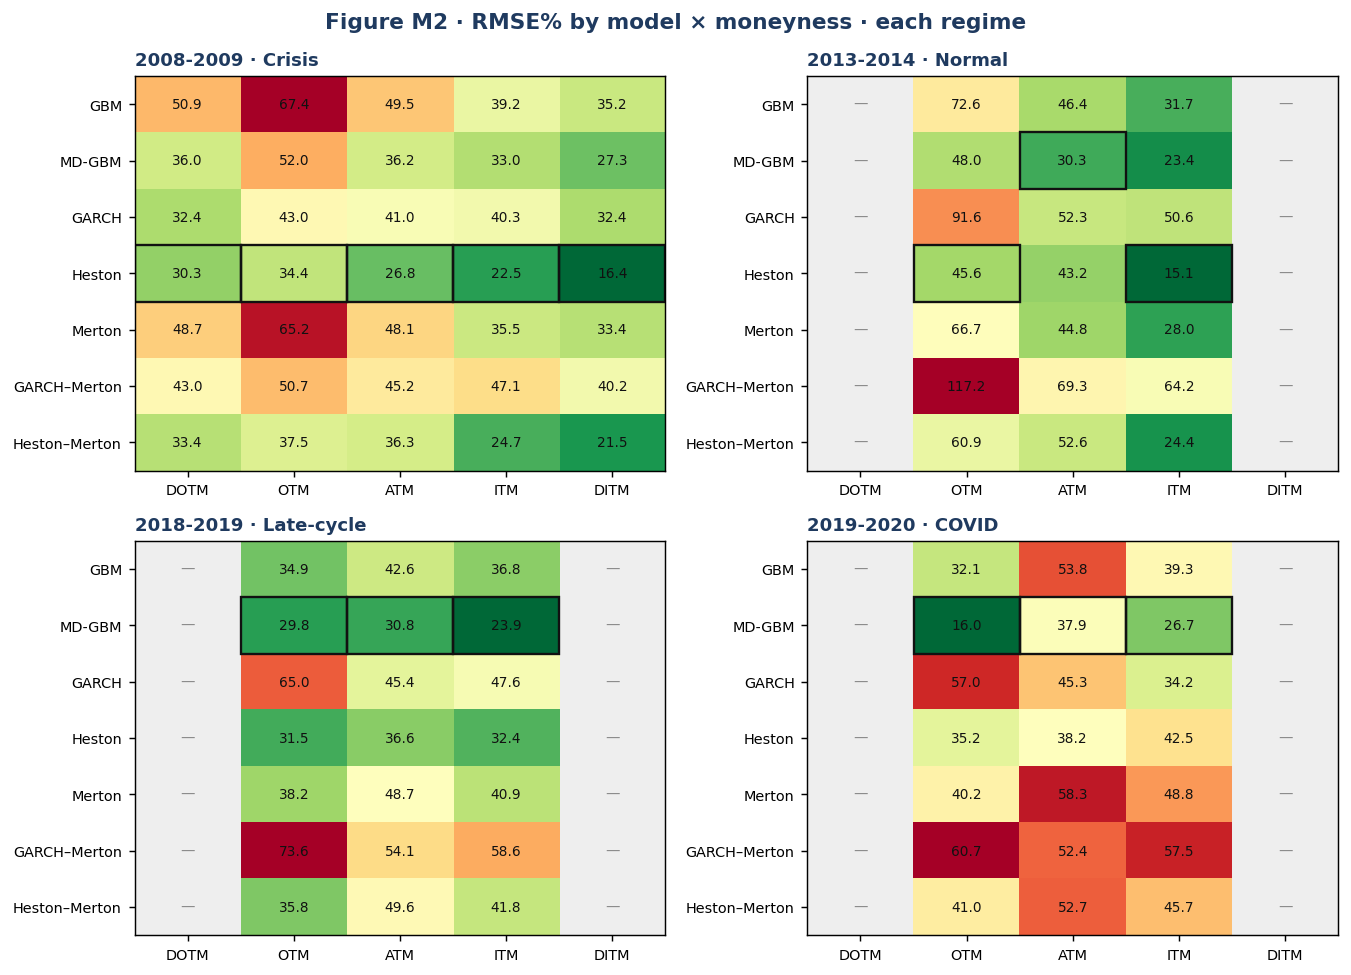

In [1]:
pass

### Table M6 — Best model by regime × moneyness


In [1]:
display(HTML('m6'))

Regime,DOTM,OTM,ATM,ITM,DITM
2008-2009,Heston,Heston,Heston,Heston,Heston
2013-2014,—,Heston,MD-GBM,Heston,—
2018-2019,—,MD-GBM,MD-GBM,MD-GBM,—
2019-2020,—,MD-GBM,MD-GBM,MD-GBM,—


### Table M7 — n by regime × moneyness


In [1]:
display(HTML('m7'))

Regime,DOTM,OTM,ATM,ITM,DITM
2008-2009,18,43,80,43,16
2013-2014,0,5,192,3,0
2018-2019,0,4,191,7,0
2019-2020,0,6,189,5,0


## 4. Findings

- DOTM (n = 18): BEST = Heston with RMSE% = 30.32, Bias% = +22.85.

- OTM (n = 58): BEST = Heston with RMSE% = 35.39, Bias% = +21.68.

- ATM (n = 652): BEST = MD-GBM with RMSE% = 33.54, Bias% = +10.33.

- ITM (n = 58): BEST = Heston with RMSE% = 25.88, Bias% = +9.88.

- DITM (n = 16): BEST = Heston with RMSE% = 16.35, Bias% = +12.19.

- Overall, the ranking does change with moneyness: DOTM → Heston, OTM → Heston, ATM → MD-GBM, ITM → Heston, DITM → Heston.

- Inside regimes, the BEST model also changes with moneyness in: 2013-2014.

- These comparisons use the Monday nearest-ATM sample, so ATM is the only well-populated bucket after 2009. DOTM/DITM results rest on few 2008–2009 quotes and should be read as descriptive, not as a high-powered test.


## 5. Re-run

```python
import run_v4_1p5y_10k_monthly_moneyness_study as mx
payload = mx.run()
```

Requires the main study contract CSVs under `V4-Models_result/results/empirical_study_1p5y_monthly_10000/contracts/`.
